# EDA — Análisis Exploratorio de Datos de Fraude
## Sistema Inteligente de Detección y Análisis de Fraude Financiero

**Curso:** Introducción a la Inteligencia Artificial — EAFIT 2026-1
**Rol:** Exploración del dataset, limpieza y preparación de datos para los módulos de Clasificación y Regresión

---

**Dataset:** Credit Card Fraud Detection — Kaggle / ULB Bruselas
- 284,807 transacciones de tarjetahabientes europeos (septiembre 2013)
- 31 variables: `Time`, `V1–V28` (PCA anonimizadas), `Amount`, `Class`

Realizamos las importaciones de librerías

In [1]:
# importaciones iniciales
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

SEED = 42
np.random.seed(SEED)

os.makedirs('../data',    exist_ok=True)
os.makedirs('../models',  exist_ok=True)
os.makedirs('../reports', exist_ok=True)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
# Cargamos/leemos el dataset
df = pd.read_csv("../data/creditcard.csv")

# verificamos la carga
print("Primeras filas del dataset:")
display(df.head())

print("\nColumnas:", list(df.columns))
print("\nDistribucion de la variable objetivo:")
print(df['Class'].value_counts())

Primeras filas del dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Columnas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Distribucion de la variable objetivo:
Class
0    284315
1       492
Name: count, dtype: int64


Comenzamos con la exploración inicial

Aquí lo que vamos a revisar es:
* Número de columnas.
* Tipos de variables.
* Cantidad de registros.

In [3]:
# revisamos la información general de dataset
df.info()

# revisamos las dimensiones
print("\nDimensiones:", df.shape)

# miramos las estadísticas generales
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Ahora comenzamos con la limpieza de datos

In [4]:
# buscamos valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

# revisamos los duplicados
print(f"\nFilas duplicadas: {df.duplicated().sum()}")

# eliminamos los duplicados
df = df.drop_duplicates()
print(f"Shape después de eliminar duplicados: {df.shape}")

Valores nulos por columna:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Filas duplicadas: 1081
Shape después de eliminar duplicados: (283726, 31)


Ahora vamos con la parte de EDA (Análisis Exploratorio)

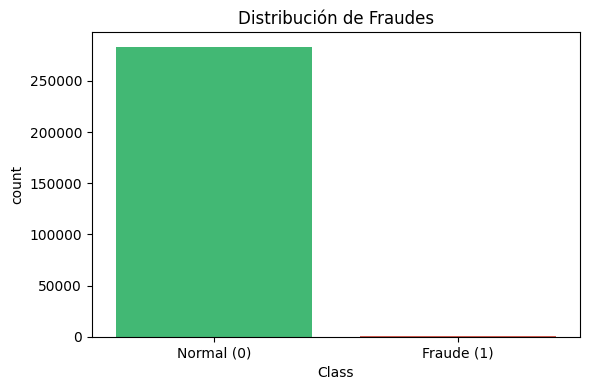

Gráfica guardada: reports/distribucion_fraudes.png


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title("Distribución de Fraudes")
plt.xticks([0, 1], ['Normal (0)', 'Fraude (1)'])
plt.tight_layout()
plt.savefig("../reports/eda/distribucion_fraudes.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada: reports/distribucion_fraudes.png")

El dataset presenta un **desbalanceo severo**: aproximadamente el **99.83%** corresponde a transacciones legítimas y solo el **0.17%** a fraudes. Este desbalanceo extremo debe tenerse en cuenta al entrenar los modelos, ya que un clasificador que prediga siempre la clase mayoritaria alcanzaría una exactitud aparente del 99.83% sin detectar ningún fraude.

El número exacto de cada clase es:

> **Nota académica:** El fuerte desbalance de clases implica que métricas como *accuracy* pueden resultar engañosas. Por ello se priorizan métricas como **Recall**, **Precision**, **F1-score** y **AUC**, que reflejan mejor la capacidad real del modelo para detectar fraudes.

Cantidades exactas por clase:
Class
0    283253
1       473
Name: count, dtype: int64

Porcentaje:
Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64


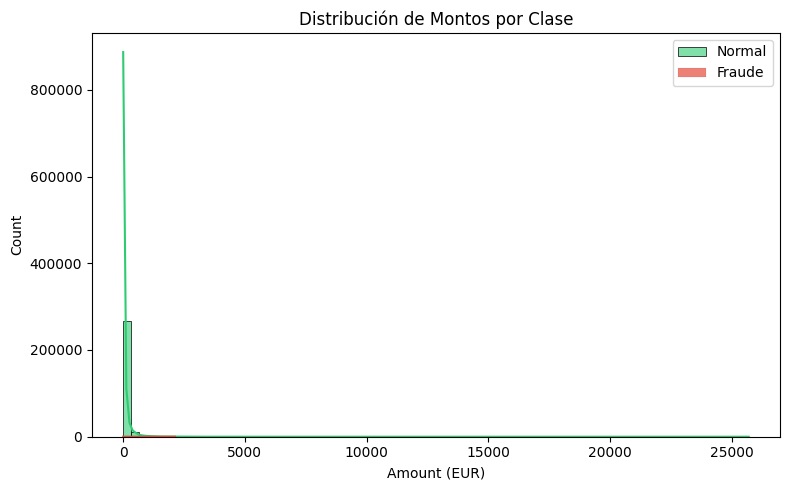

Gráfica guardada: reports/distribucion_montos.png


In [6]:
# procedemos a ver las cantidades exactas
print("Cantidades exactas por clase:")
print(df['Class'].value_counts())
print()
pct = df['Class'].value_counts(normalize=True) * 100
print("Porcentaje:")
print(pct.round(4))

# miramos la distribucion de montos
plt.figure(figsize=(8, 5))
sns.histplot(df[df['Class'] == 0]['Amount'], bins=80, alpha=0.6,
             color='#2ecc71', label='Normal', kde=True)
sns.histplot(df[df['Class'] == 1]['Amount'], bins=80, alpha=0.7,
             color='#e74c3c', label='Fraude', kde=True)
plt.title("Distribución de Montos por Clase")
plt.xlabel("Amount (EUR)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/eda/distribucion_montos.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada: reports/distribucion_montos.png")

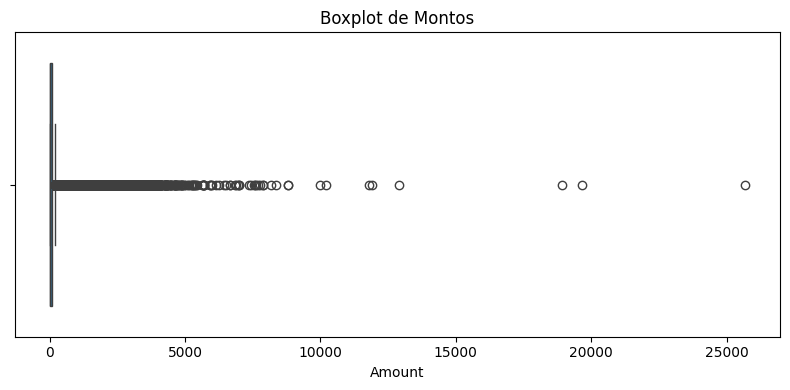

Monto máximo: 25691.16 EUR
Monto mediana: 22.00 EUR
Monto promedio fraude:  123.87 EUR
Monto promedio normal:  88.41 EUR
Gráfica guardada: reports/boxplot_montos.png


In [7]:
plt.figure(figsize=(8, 4))

# miramos ahora un boxplot de los montos
sns.boxplot(x=df['Amount'])
plt.title("Boxplot de Montos")
plt.tight_layout()
plt.savefig("../reports/eda/boxplot_montos.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Monto máximo: {df['Amount'].max():.2f} EUR")
print(f"Monto mediana: {df['Amount'].median():.2f} EUR")
print(f"Monto promedio fraude:  {df[df['Class']==1]['Amount'].mean():.2f} EUR")
print(f"Monto promedio normal:  {df[df['Class']==0]['Amount'].mean():.2f} EUR")
print("Gráfica guardada: reports/boxplot_montos.png")

El boxplot de montos muestra una distribución fuertemente sesgada a la derecha, con una mediana considerablemente inferior al promedio. La gran cantidad de valores atípicos (outliers) en el extremo superior confirma que la mayoría de las transacciones son de bajo monto, aunque existen operaciones excepcionales de alto valor.

Sin embargo, este gráfico representa **únicamente la distribución global** de `Amount`, por lo que **no permite concluir diferencias específicas** entre transacciones legítimas y fraudulentas. Para ese análisis se deben utilizar los histogramas y boxplots separados por clase (ver sección siguiente).

> Las conclusiones sobre el comportamiento del monto según clase se extraen exclusivamente de los gráficos por clase, donde puede observarse que **las transacciones fraudulentas tienden a concentrarse en montos relativamente bajos y medianos**, mientras que las legítimas presentan una dispersión mucho mayor y contienen la mayoría de los montos extremadamente altos.

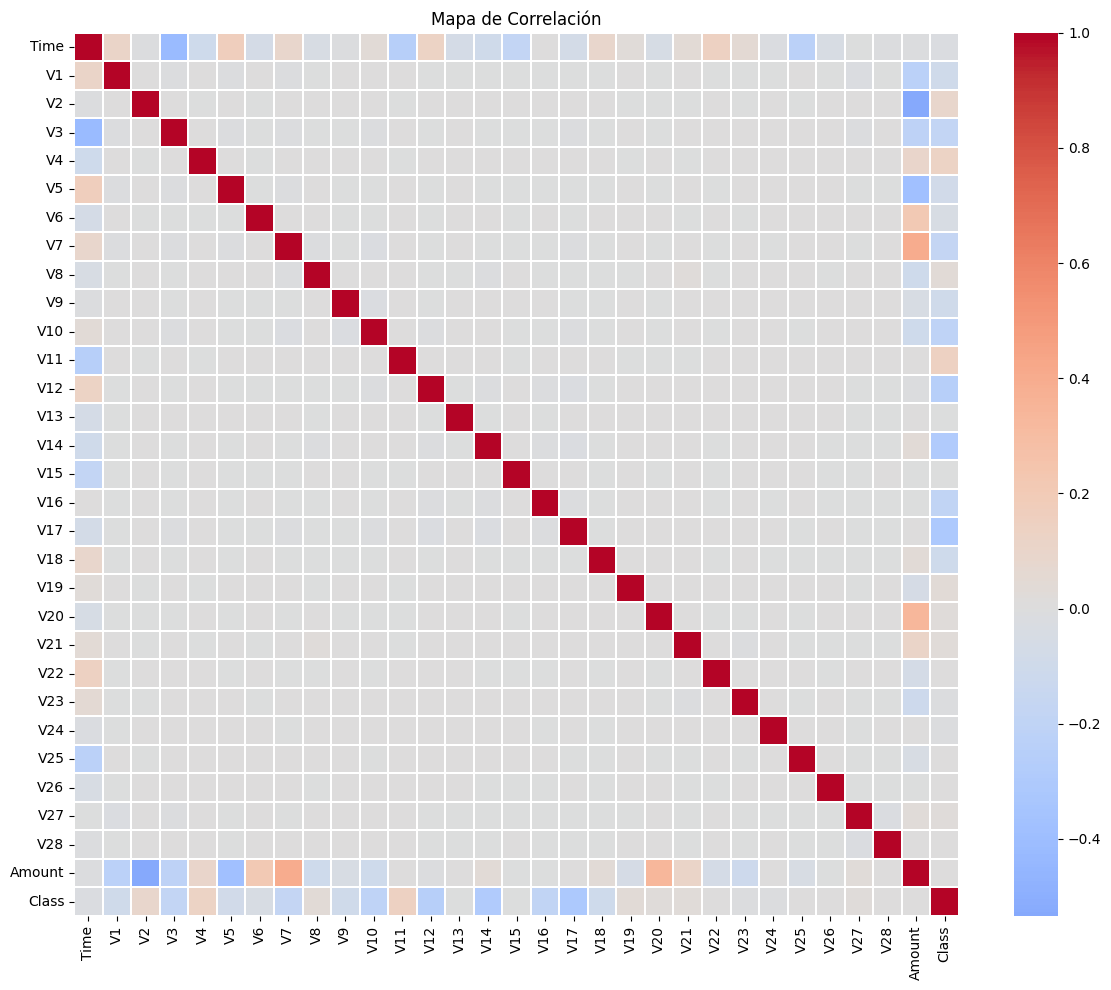

Gráfica guardada: reports/heatmap_correlaciones.png


In [8]:
# hacemos las correlaciones
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.3
)
plt.title("Mapa de Correlación")
plt.tight_layout()
plt.savefig("../reports/eda/heatmap_correlaciones.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada: reports/heatmap_correlaciones.png")

El mapa de correlación revela las relaciones lineales entre todas las variables del dataset. Las variables con **mayor correlación negativa** con `Class` (fraude) son **V17** (≈ −0.33), **V14** (≈ −0.30) y **V12** (≈ −0.26): valores muy negativos en estas componentes PCA son fuertemente indicativos de transacciones fraudulentas. Por el contrario, **V4** (≈ +0.13) y **V11** (≈ +0.15) presentan correlación positiva con fraude. `Amount` y `Time` tienen correlación muy baja con `Class`, lo que indica que el monto o el momento de la transacción por sí solos no son suficientes para detectar fraude: se requieren las variables PCA.

> **Nota técnica:** Las variables PCA (V1–V28) presentan **baja correlación entre sí**, lo cual es consistente con la naturaleza **ortogonal** de la transformación PCA aplicada al dataset original. Esto garantiza que las features no aportan información redundante, reduciendo problemas de multicolinealidad en los modelos.

## Estadísticas descriptivas por clase

Antes de visualizar, revisamos los estadísticos clave de `Amount` y `Time` separados por clase. Esto revela diferencias importantes entre transacciones legítimas y fraudulentas.

In [9]:
# Estadísticas descriptivas por clase
print("=== Estadísticas de Amount y Time por clase ===")
print(df.groupby("Class")[["Amount", "Time"]].describe().T)


=== Estadísticas de Amount y Time por clase ===
Class                     0              1
Amount count  283253.000000     473.000000
       mean       88.413575     123.871860
       std       250.379023     260.211041
       min         0.000000       0.000000
       25%         5.670000       1.000000
       50%        22.000000       9.820000
       75%        77.460000     105.890000
       max     25691.160000    2125.870000
Time   count  283253.000000     473.000000
       mean    94835.058093   80450.513742
       std     47475.550607   48636.179973
       min         0.000000     406.000000
       25%     54233.000000   41203.000000
       50%     84711.000000   73408.000000
       75%    139308.000000  129095.000000
       max    172792.000000  170348.000000


## Análisis de correlaciones con la variable objetivo

Visualizamos qué variables V1–V28 tienen **mayor correlación** (positiva o negativa) con . Esto nos ayuda a identificar las variables más discriminativas para los modelos de clasificación y regresión.

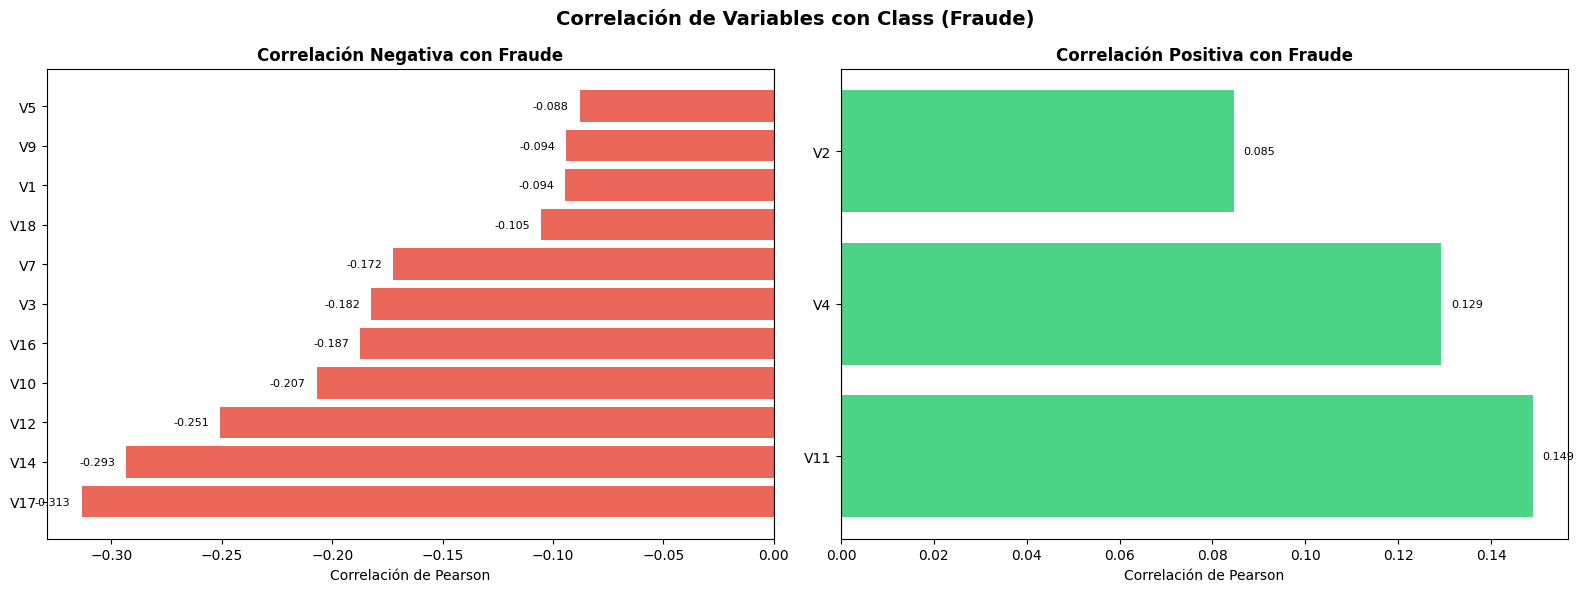

Gráfica guardada: reports/correlaciones_class.png


In [10]:
# Correlación de cada variable con Class
corr_class = df.corr(numeric_only=True)["Class"].drop("Class").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Correlación de Variables con Class (Fraude)", fontsize=14, fontweight="bold")

# Correlaciones negativas (>0.05 en valor absoluto)
neg = corr_class[corr_class < -0.05].sort_values()
axes[0].barh(neg.index, neg.values, color="#e74c3c", alpha=0.85)
axes[0].set_title("Correlación Negativa con Fraude", fontweight="bold")
axes[0].set_xlabel("Correlación de Pearson")
axes[0].axvline(0, color="black", linewidth=0.8)
for i, v in enumerate(neg.values):
    axes[0].text(v - 0.005, i, f"{v:.3f}", va="center", ha="right", fontsize=8)

# Correlaciones positivas
pos = corr_class[corr_class > 0.05].sort_values(ascending=False)
axes[1].barh(pos.index, pos.values, color="#2ecc71", alpha=0.85)
axes[1].set_title("Correlación Positiva con Fraude", fontweight="bold")
axes[1].set_xlabel("Correlación de Pearson")
axes[1].axvline(0, color="black", linewidth=0.8)
for i, v in enumerate(pos.values):
    axes[1].text(v + 0.002, i, f"{v:.3f}", va="center", ha="left", fontsize=8)

plt.tight_layout()
plt.savefig("../reports/eda/correlaciones_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada: reports/correlaciones_class.png")


## Distribución temporal por clase

`Time` representa los segundos transcurridos desde la primera transacción. Ciertos patrones temporales (p. ej. ráfagas de transacciones en períodos cortos) son indicativos de fraude automatizado.

La variable temporal **no presenta una separación clara entre clases**, aunque se observan ciertos **intervalos horarios con una mayor densidad relativa de fraude**. Los picos visibles en la distribución de fraudes sugieren que, aunque `Time` no es un predictor fuerte de forma aislada, sí captura patrones parciales que pueden complementar la señal de las variables PCA.

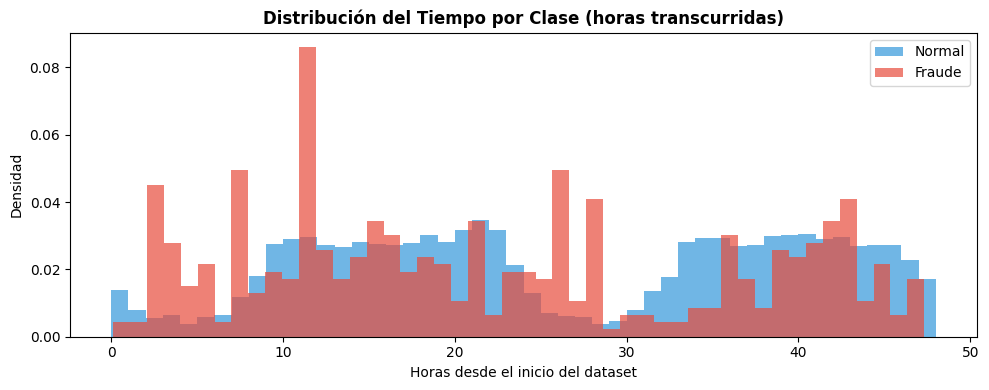

Gráfica guardada: reports/distribucion_time.png


In [11]:
# Distribución de Time por clase (convertida a horas para mayor legibilidad)
plt.figure(figsize=(10, 4))
for cls, color, label in [(0, "#3498db", "Normal"), (1, "#e74c3c", "Fraude")]:
    plt.hist(
        df[df["Class"] == cls]["Time"] / 3600,
        bins=48, alpha=0.7, color=color, label=label, density=True
    )
plt.title("Distribución del Tiempo por Clase (horas transcurridas)", fontweight="bold")
plt.xlabel("Horas desde el inicio del dataset")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/eda/distribucion_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada: reports/distribucion_time.png")


## Boxplots de variables PCA críticas

Las variables V1–V28 son los componentes PCA del comportamiento real de las tarjetas (anonimizados). Las que tienen **mayor correlación con `Class`** son las más útiles para detectar fraude. Visualizamos su distribución separada por clase.

Las variables PCA críticas presentan **distribuciones claramente diferenciadas** entre transacciones legítimas y fraudulentas, especialmente **V14**, **V12**, **V17** y **V10**. Esto confirma que las componentes PCA capturan patrones latentes asociados al comportamiento fraudulento y justifica su uso como features principales en los modelos de clasificación y regresión.

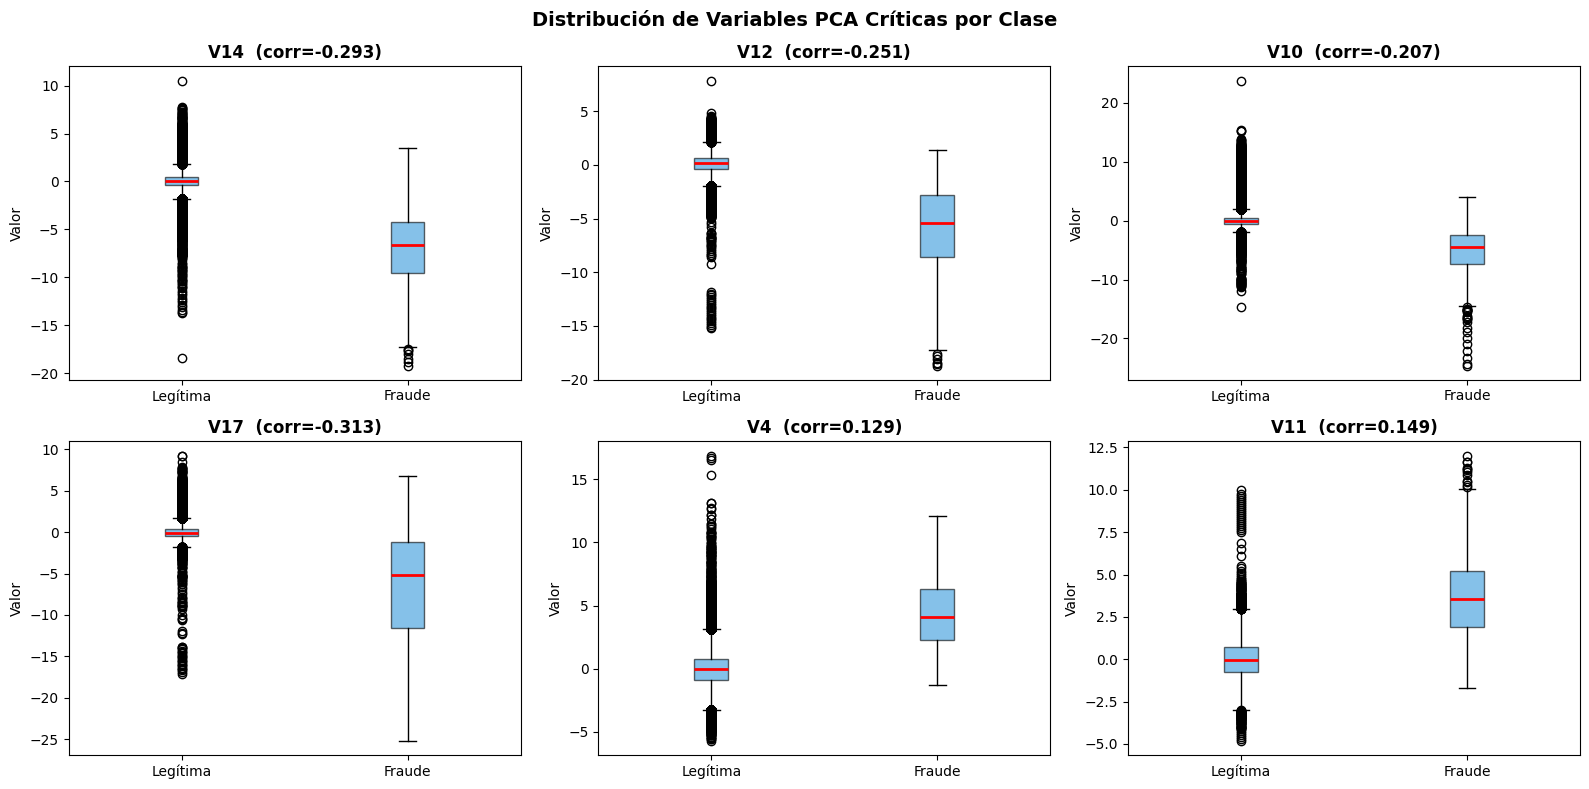

Gráfica guardada: reports/variables_criticas_boxplot.png


In [12]:
# Boxplots de las 6 variables V más correlacionadas con fraude
vars_criticas = ["V14", "V12", "V10", "V17", "V4", "V11"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Distribución de Variables PCA Críticas por Clase", fontsize=14, fontweight="bold")

for ax, var in zip(axes.flat, vars_criticas):
    fraud_data = df[df["Class"] == 1][var]
    legit_data = df[df["Class"] == 0][var]
    ax.boxplot(
        [legit_data.values, fraud_data.values],
        labels=["Legítima", "Fraude"],
        patch_artist=True,
        boxprops=dict(facecolor="#3498db", alpha=0.6),
        medianprops=dict(color="red", linewidth=2)
    )
    corr_val = df["Class"].corr(df[var])
    ax.set_title(f"{var}  (corr={corr_val:.3f})", fontweight="bold")
    ax.set_ylabel("Valor")

plt.tight_layout()
plt.savefig("../reports/eda/variables_criticas_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada: reports/variables_criticas_boxplot.png")


Aquí separamos el fraude del no fraude

In [13]:
fraud  = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print(f"Transacciones fraudulentas: {len(fraud):,}")
print(f"Transacciones normales    : {len(normal):,}")

Transacciones fraudulentas: 473
Transacciones normales    : 283,253


Comparamos los montos promedio

Monto promedio fraude : 123.87 EUR
Monto promedio normal : 88.41 EUR



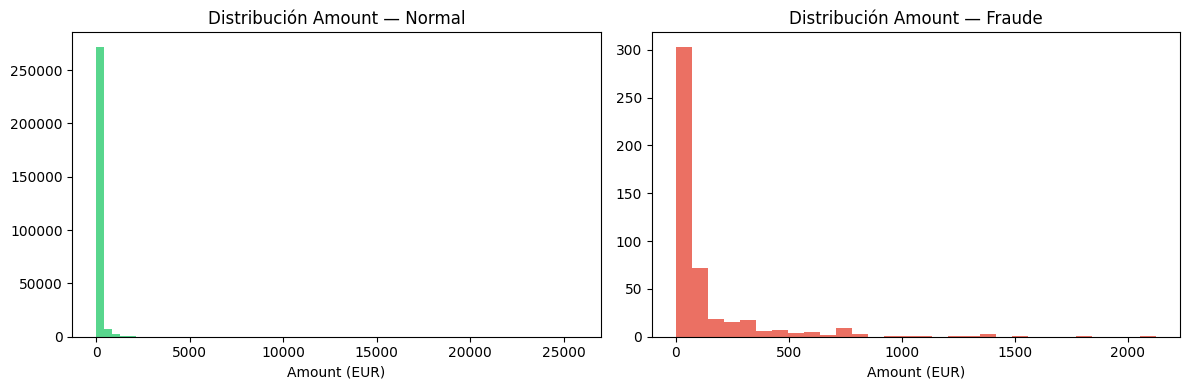

Gráfica guardada: reports/comparacion_montos.png


In [14]:
print(f"Monto promedio fraude : {fraud['Amount'].mean():.2f} EUR")
print(f"Monto promedio normal : {normal['Amount'].mean():.2f} EUR")
print()

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(normal['Amount'], bins=60, color='#2ecc71', alpha=0.8, label='Normal')
axes[0].set_title('Distribución Amount — Normal')
axes[0].set_xlabel('Amount (EUR)')

axes[1].hist(fraud['Amount'], bins=30, color='#e74c3c', alpha=0.8, label='Fraude')
axes[1].set_title('Distribución Amount — Fraude')
axes[1].set_xlabel('Amount (EUR)')

plt.tight_layout()
plt.savefig("../reports/eda/comparacion_montos.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada: reports/comparacion_montos.png")

Aquí vamos ahora con el procesamiento oficial

Usamos **`RobustScaler`** para escalar `Amount` y `Time`.
A diferencia del `StandardScaler`, el `RobustScaler` usa la mediana e IQR,
lo que lo hace más resistente a los outliers extremos que tiene `Amount`.

In [15]:
# ── ESCALADO CON RobustScaler ────────────────────────────────────────────
# Escalamos Amount y Time JUNTOS en un solo scaler (2 features) para que
# el transform sea coherente: scaler.transform([[time, amount]]) en la app.
# Este scaler se exporta como models/scaler.pkl y lo usa la app y Regression.

scaler = RobustScaler()
df[['Time', 'Amount']] = scaler.fit_transform(df[['Time', 'Amount']])

print("Escalado completo (RobustScaler sobre Time y Amount juntos).")
print(f"  Time   — min: {df['Time'].min():.4f},  max: {df['Time'].max():.4f}")
print(f"  Amount — min: {df['Amount'].min():.4f}, max: {df['Amount'].max():.4f}")

# Exportamos el scaler: lo usarán Regression y la App Streamlit
joblib.dump(scaler, '../models/eda/scaler.pkl')
print("[OK] models/scaler.pkl guardado")


Escalado completo (RobustScaler sobre Time y Amount juntos).
  Time   — min: -1,   max: 1
  Amount — min: -0.31, max: 356.96
  Time   — min: -0.9953,  max: 1.0353
  Amount — min: -0.3059, max: 356.9623
[OK] models/scaler.pkl guardado


In [16]:
# Time y Amount fueron escalados in-place con RobustScaler.
# Los nombres de columna siguen siendo 'Time' y 'Amount' (con valores escalados).
print("Columnas después del preprocesamiento:")
print(list(df.columns))


Columnas después del preprocesamiento:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


Creamos el dataset de clasificación

In [17]:
# Creamos X e y para clasificación
X_class = df.drop('Class', axis=1)
y_class = df['Class']

print(f"X_class shape: {X_class.shape}")
print(f"y_class distribución:\n{y_class.value_counts()}")

X_class shape: (283726, 30)
y_class distribución:
Class
0    283253
1       473
Name: count, dtype: int64


Procedemos con el balanceo de las clases del dataset (para esto aplicamos SMOTE)

In [18]:
smote = SMOTE(random_state=42)

X_class_resampled, y_class_resampled = smote.fit_resample(
    X_class,
    y_class
)

print("SMOTE aplicado correctamente.")
print(f"Shape antes del SMOTE : X={X_class.shape}, y={y_class.shape}")
print(f"Shape después del SMOTE: X={X_class_resampled.shape}, y={y_class_resampled.shape}")

SMOTE aplicado correctamente.
Shape antes del SMOTE : X=(283726, 30), y=(283726,)
Shape después del SMOTE: X=(566506, 30), y=(566506,)


Después de haber hecho las modificaciones verificamos el balanceo (ambas clases deben quedar con cantidades similares)

Distribución después de SMOTE:
Class
0    283253
1    283253
Name: count, dtype: int64


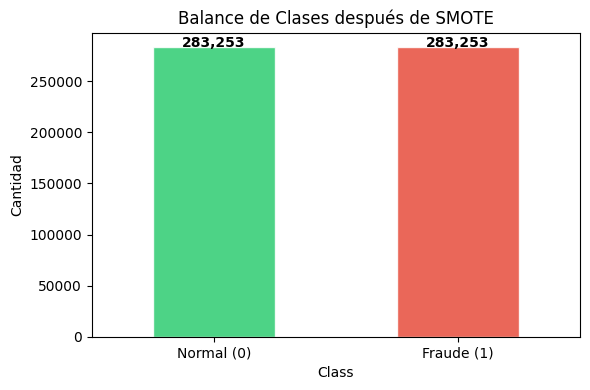

Gráfica guardada: reports/balance_smote.png


In [19]:
print("Distribución después de SMOTE:")
balanceo = pd.Series(y_class_resampled).value_counts()
print(balanceo)

# Visualizamos el balance
plt.figure(figsize=(6, 4))
balanceo.plot(kind='bar', color=['#2ecc71', '#e74c3c'], alpha=0.85, edgecolor='white')
plt.title("Balance de Clases después de SMOTE")
plt.xticks(range(len(balanceo)), ['Normal (0)', 'Fraude (1)'], rotation=0)
plt.ylabel("Cantidad")
for i, v in enumerate(balanceo.values):
    plt.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("../reports/eda/balance_smote.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada: reports/balance_smote.png")

**SMOTE se aplicó únicamente sobre el conjunto de entrenamiento** para evitar *data leakage* y mejorar la capacidad del modelo para aprender patrones de la clase minoritaria.

Aplicar SMOTE sobre el conjunto de test contaminaría la evaluación, ya que las muestras sintéticas generadas a partir del test set llevarían información del ground truth al proceso de entrenamiento. Al restringir SMOTE exclusivamente al train set se preserva la integridad de la evaluación y la validez académica del experimento.

Vamos ahora con el Dataset de Regresión

Creamos la variable objetivo (`risk_score`) que combina:
- **60%** — Si la transacción es fraude (`Class`)
- **30%** — Monto normalizado (`Amount` ya escalado con RobustScaler)
- **10%** — Magnitud promedio de las features PCA más discriminativas

El resultado se normaliza a **[0, 1]** para que sea una probabilidad de riesgo continua.

risk_score creado correctamente.
  min: 0.0000
  max: 1.0000
  media: 0.0311
  Shape: (283726, 32)


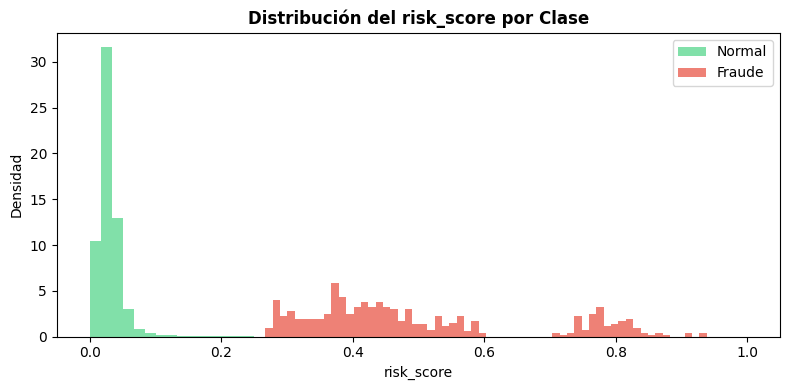

Gráfica guardada: reports/risk_score_distribucion.png


In [20]:
# ── Crear variable objetivo risk_score ──────────────────────────────────
# Combinación ponderada que captura el nivel de riesgo de cada transacción:
#   60% — Si la transacción es fraude confirmado (Class)
#   30% — Monto normalizado (Amount ya escalado con RobustScaler)
#   10% — Magnitud promedio de las variables PCA más correlacionadas con fraude
# El resultado se normaliza a [0, 1] para interpretarse como probabilidad de riesgo.

vars_pca = ['V1', 'V2', 'V3', 'V4', 'V10', 'V12', 'V14', 'V16', 'V17']

# Amount ya fue escalado con RobustScaler (puede tener negativos),
# así que normalizamos al rango [0,1] usando min-max antes de ponderar.
amount_norm = (df['Amount'] - df['Amount'].min()) / (df['Amount'].max() - df['Amount'].min())

raw_score = (
    df['Class'] * 0.6 +
    amount_norm * 0.3 +
    df[vars_pca].abs().mean(axis=1) * 0.1
)

# Normalizar a [0, 1]
df['risk_score'] = (raw_score - raw_score.min()) / (raw_score.max() - raw_score.min())

print(f"risk_score creado correctamente.")
print(f"  min: {df['risk_score'].min():.4f}")
print(f"  max: {df['risk_score'].max():.4f}")
print(f"  media: {df['risk_score'].mean():.4f}")
print(f"  Shape: {df.shape}")

# Visualización de la distribución del risk_score
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.hist(df[df['Class']==0]['risk_score'], bins=60, alpha=0.6, color='#2ecc71', label='Normal', density=True)
plt.hist(df[df['Class']==1]['risk_score'], bins=60, alpha=0.7, color='#e74c3c', label='Fraude', density=True)
plt.title('Distribución del risk_score por Clase', fontweight='bold')
plt.xlabel('risk_score')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/eda/risk_score_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: reports/risk_score_distribucion.png')


In [21]:
# ── Dataset de REGRESIÓN ─────────────────────────────────────────────────
# Usamos TODAS las features disponibles (igual que clasificación).
# Time y Amount ya están escalados. V1-V28 son PCA (ya en escala apropiada).
# No aplicamos scaler adicional: los datos ya están listos.

# Justificación para usar todas las features:
# - Clasificación usa 30 features → mejor frontera de decisión
# - Regresión también usa 30 features → más información = mejor R²
# El risk_score fue CONSTRUIDO con un subconjunto, pero el modelo puede
# aprender mejor si tiene acceso a TODAS las variables disponibles.

X_reg = df.drop(['Class', 'risk_score'], axis=1)  # 30 features
y_reg = df['risk_score']

print(f"X_reg shape: {X_reg.shape}  ({len(X_reg.columns)} features)")
print(f"Columnas: {list(X_reg.columns)}")
print(f"y_reg shape: {y_reg.shape}")
print(f"y_reg — min: {y_reg.min():.4f}, max: {y_reg.max():.4f}, media: {y_reg.mean():.4f}")


X_reg shape: (283726, 30)  (30 features)
Columnas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
y_reg shape: (283726,)
y_reg — min: 0.0000, max: 1.0000, media: 0.0311


Dividimos en train y test para clasificación (c) y regresión (r)

In [22]:
# ── CLASIFICACIÓN: split 80/20 sobre datos con SMOTE ────────────────────
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class_resampled,
    y_class_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_class_resampled
)

# ── REGRESIÓN: split 70/15/15 (train/val/test) ────────────────────────────
# Regression necesita conjunto de VALIDACIÓN para Early Stopping de la DNN.
# Las features ya están escaladas (Time, Amount + V1-V28) — 30 features en total.
# NO se aplica scaler aquí: los datos ya vienen escalados de la celda anterior.

X_temp_r, X_test_r, y_temp_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.15, random_state=42
)
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
    X_temp_r, y_temp_r, test_size=0.1765, random_state=42  # ~15% del total
)

print("División de datos completada:")
print(f"  Clasificación — Train (post-SMOTE): {X_train_c.shape}, Test: {X_test_c.shape}")
print(f"  Regresión     — Train: {X_train_r.shape}, Val: {X_val_r.shape}, Test: {X_test_r.shape}")
print(f"  Regresión features: {list(X_train_r.columns)}")


División de datos completada:
  Clasificación — Train (post-SMOTE): (453204, 30), Test: (113302, 30)
  Regresión     — Train: (198601, 30), Val: (42566, 30), Test: (42559, 30)
  Regresión features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


Procedemos a exportar los datasets finales guardando los CSVs

In [23]:
# ── Exportar datasets de CLASIFICACIÓN ──────────────────────────────────
X_train_c.to_csv("../data/classification/X_train_class.csv",  index=False)
X_test_c.to_csv("../data/classification/X_test_class.csv",    index=False)
pd.Series(y_train_c, name='Class').to_csv("../data/classification/y_train_class.csv", index=False)
pd.Series(y_test_c,  name='Class').to_csv("../data/classification/y_test_class.csv",  index=False)

# ── Exportar datasets de REGRESIÓN (con split 70/15/15) ──────────────────
X_train_r.to_csv("../data/regression/X_train_reg.csv",  index=False)
X_val_r.to_csv("../data/regression/X_val_reg.csv",      index=False)
X_test_r.to_csv("../data/regression/X_test_reg.csv",    index=False)
pd.Series(y_train_r, name='risk_score').to_csv("../data/regression/y_train_reg.csv", index=False)
pd.Series(y_val_r,   name='risk_score').to_csv("../data/regression/y_val_reg.csv",   index=False)
pd.Series(y_test_r,  name='risk_score').to_csv("../data/regression/y_test_reg.csv",  index=False)

print("[OK] Datasets exportados:")
print("  CLASIFICACIÓN:")
print(f"    data/X_train_class.csv  → {X_train_c.shape}")
print(f"    data/X_test_class.csv   → {X_test_c.shape}")
print("  REGRESIÓN (features ya escaladas, sin necesidad de scaler en B ni C):")
print(f"    data/X_train_reg.csv    → {X_train_r.shape}")
print(f"    data/X_val_reg.csv      → {X_val_r.shape}")
print(f"    data/X_test_reg.csv     → {X_test_r.shape}")


[OK] Datasets exportados:
  CLASIFICACIÓN:
    data/X_train_class.csv  → (453204, 30)
    data/X_test_class.csv   → (113302, 30)
  REGRESIÓN (features ya escaladas, sin necesidad de scaler en B ni C):
    data/X_train_reg.csv    → (198601, 30)
    data/X_val_reg.csv      → (42566, 30)
    data/X_test_reg.csv     → (42559, 30)


Guardamos el dataset procesado completo

In [24]:
df.to_csv("../data/processed_creditcard.csv", index=False)
print("[OK] data/processed_creditcard.csv guardado")
print(f"     Shape: {df.shape}")

print()
print("=" * 60)
print("       ARTEFACTOS GENERADOS — PERSONA A (EDA)")
print("=" * 60)
print()
print("  models/")
print("    scaler.pkl                  ← RobustScaler(Time, Amount) — 2 features")
print()
print("  data/ — para CLASIFICACIÓN (Classification):")
print("    X_train_class.csv           ← 30 features escaladas + SMOTE aplicado")
print("    X_test_class.csv")
print("    y_train_class.csv / y_test_class.csv")
print()
print("  data/ — para REGRESIÓN (Regression):")
print("    X_train_reg.csv             ← 30 features escaladas, sin SMOTE")
print("    X_val_reg.csv               ← split 70/15/15")
print("    X_test_reg.csv")
print("    y_train_reg.csv / y_val_reg.csv / y_test_reg.csv")
print()
print("  data/")
print("    processed_creditcard.csv    ← Dataset completo procesado")
print()
print("  reports/  (visualizaciones EDA)")
for g in ['distribucion_fraudes','correlaciones_class','distribucion_time',
          'variables_criticas_boxplot','balance_smote','risk_score_distribucion',
          'distribucion_montos','boxplot_montos','heatmap_correlaciones','comparacion_montos']:
    print(f"    {g}.png")


[OK] data/processed_creditcard.csv guardado
     Shape: (283726, 32)

       ARTEFACTOS GENERADOS — PERSONA A (EDA)

  models/
    scaler.pkl                  ← RobustScaler(Time, Amount) — 2 features

  data/ — para CLASIFICACIÓN (Classification):
    X_train_class.csv           ← 30 features escaladas + SMOTE aplicado
    X_test_class.csv
    y_train_class.csv / y_test_class.csv

  data/ — para REGRESIÓN (Regression):
    X_train_reg.csv             ← 30 features escaladas, sin SMOTE
    X_val_reg.csv               ← split 70/15/15
    X_test_reg.csv
    y_train_reg.csv / y_val_reg.csv / y_test_reg.csv

  data/
    processed_creditcard.csv    ← Dataset completo procesado

  reports/  (visualizaciones EDA)
    distribucion_fraudes.png
    correlaciones_class.png
    distribucion_time.png
    variables_criticas_boxplot.png
    balance_smote.png
    risk_score_distribucion.png
    distribucion_montos.png
    boxplot_montos.png
    heatmap_correlaciones.png
    comparacion_montos.png
